## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 3 (Section 006, Fall 2025)

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of 100 possible on this quiz and each part of the quiz can be done independently. **If you get stuck _move on to another part of the quiz to earn some points there!_**

### ANSWER (for making sure this gets removed) ###

## Template Guidelines

**Learning Objectives from Homework 3:**
- Using pandas to work with data and clean it
- Make meaningful visual representations of the data
- Fitting curves to data and evaluating model fit

**Learning Objectives the Quiz will assess:**
* Loading and manipulating (e.g. filtering, calculating basic statistics) data using Pandas
* Using curve_fit to fit models to data and find best fit model parameters
* Using best fit parameters to calculate expected model values
* Visualizing data and models using matplotlib

**Quiz Duration:** 30 minutes (ideally, time can be extended slightly if needed)
* This means your TAs/LAs should be able to complete the quiz in at most 10 minutes (if TA/LA completion time is closer to 15, consider extending quiz to 40 minutes)

**Notes:**
* The structure and rubric provided here is a suggestion and an example of the difficulty level expected. However, as long as your quiz assesses the learning objectives listed under "Learning Objectives the Quiz will assess" section above, you can differ from this structure. If you aren't sure that your quiz does that, run it by another instructor (lead isntructor, other faculty, TA, or LA)
* The examples provided are examples and **should not be used directly without changes in any quizzes**
* These quizzes are important for students to assess how well they understand the material independent of their groups, so when grading, be sure to provide feedback on where points were deducted. **You should also have a clear rubric with clearly stated point values, but you do not need to follow the point values included in this template**.
* Quizzes should be written with ample time for TAs/LAs to review! **Your TA and LAs should have at least 48 hours to review the quiz before it is given**.
* Quizzes (and instructor solution with point-by-point rubrics) should be **pushed to the GitHub repo for record-keeping**. Put your section's version in a sub-folder with the name `Section-###` where "###" is your section number.

**Overall Structure:**

1. A section that focuses on assessing if students correctly load a CSV file (that they haven't seen before) using Pandas and then explores if they have mastered the ability to mask data for the purposes of filtering the data and can calculate basic statistical values.
2. A section that uses some provided data (so as not to penalize them again for not having mastered loading data) and a model function to find the best fit parameters for the model using curve_fit. This question should also assess if they can use those best fit parameters to produce the expected model values and then use matplotlib to visualize their model and compare it to the data.
3. It is also strongly recommended that you include documenting solution pathways questions!

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.

**NOTE: If you use generative AI, you must copy/paste into a cell in this quiz (1) your prompt, (2) the output from generative AI, and (3) Write your answer in separate cells. Failure to include this level of detail will result in a deduction of points.**

<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---

# 1. Analyzing Iris Flower Dataset (50 points)

You’re embedded with a **botanical survey team** that’s cataloging wild irises at several sites. Your job is to use quick caliper measurements to help the field crew **triage specimens**: flag unusual plants, summarize site-level trends, and later build simple models that relate morphology to species identity. Data source: the canonical Iris data set (Fisher, 1936), originally used to illustrate linear discriminant analysis; here we use a cleaned copy as a stand-in for field measurements—standardized to centimeters with verified species labels for rapid triage.

**About the dataset (cleaned Iris):**
- **Samples:** 150 iris flowers *(~50 each of `setosa`, `versicolor`, `virginica`)*  
- **No missing values** (already cleaned for you)
- **Columns (units):**
  - `sepal_length_cm` — sepal length (cm)
  - `sepal_width_cm` — sepal width (cm)
  - `petal_length_cm` — petal length (cm)
  - `petal_width_cm` — petal width (cm)
  - `species` — species label (`setosa`, `versicolor`, `virginica`)

**Why this matters:**  
The crew needs quick, data-informed checks in the field. In this part you’ll:
- **Load** and **preview** the measurements to sanity-check the data,
- **Filter (mask)** to focus on plausible ranges/species of interest,
- **Summarize** key statistics to guide decisions (e.g., “are these flowers unusually small for this site?”),
- (Later) **visualize** relationships and **fit** simple models.

> Tip: Keep track of units (cm) and verify shapes and head rows as you go—those fast checks prevent downstream mistakes.

#### &#9989;&nbsp; **Question 1.1 (5 points)** — Load & preview field measurements

Field context: The crew just radioed in a fresh CSV export of caliper measurements from today’s transects. Before anyone makes decisions in the field, you need to sanity-check the file: do the columns look right, and do the first few rows have plausible values?

**YOUR TASK:** Using **Pandas**, read `quiz3_iris_clean.csv` and display the **first 10 rows**.

In [4]:
# PUT YOUR CODE HERE
import pandas as pd

fname = "quiz3_iris_clean.csv"

# 1) Load the CSV into a DataFrame named df
# 2) Display the first 10 rows (sanity check columns/units/values)


In [5]:
### ANSWER
import pandas as pd

fname = "quiz3_iris_clean.csv"
df = pd.read_csv(fname)

df.head(10)


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


#### &#9989;&nbsp; **Question 1.2 (15 points)**  — Mask to a triage subset

For a quick mid-shift snapshot, the lead botanist wants to focus on **non-setosa flowers** with a typical **sepal length** range (extremes will be investigated separately). This helps catch outliers without overloading the team.

**YOUR TASK:** Create a masked DataFrame `df_masked` that:

- Excludes rows where species == "setosa", and
- Keeps rows with sepal_length_cm between 5.0 and 7.0 (inclusive).

Print `df_masked.shape` and show its first 5 rows.

**Note**: if you didn't get the dataset loaded correctly, try your best to write the code that **should** appropriately mask the data for partial credit.

In [6]:
# PUT YOUR CODE HERE



In [7]:
### ANSWER


cond_species = (df["species"] != "setosa")
cond_length  = (df["sepal_length_cm"] >= 5.0) & (df["sepal_length_cm"] <= 7.0)

df_masked = df[cond_species & cond_length].copy()

print("df_masked.shape:", df_masked.shape)
df_masked.head(5)

# Rubric
# 5 points for any masking attempt
# 5 points for a correct mask
# 5 points for display

df_masked.shape: (86, 5)


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor


#### &#9989;&nbsp; **Question 1.3 (10 points)** — Quick stats for the field lead

The lead needs fast, interpretable numbers to decide whether today’s specimens look typical for this site. Compute summary statistics on the triage subset.

**YOUR TASK:** For `df_masked`, calculate **mean** for:
`sepal_length_cm`, `sepal_width_cm`, `petal_length_cm`, `petal_width_cm`.

**Note #1**: there's more than one way you could do this.

**Note #2**: if you didn't get the dataset loaded correctly, try your best to write the code that **should** calculate and display the mean for partial credit.

In [8]:
# PUT YOUR CODE HERE


In [9]:
### ANSWER
num_cols = ["sepal_length_cm","sepal_width_cm","petal_length_cm","petal_width_cm"]

# Option 1: Using "describe"
print(df_masked[num_cols].describe())

# Option 2: Using "mean"
print(df_masked[num_cols].mean())

# Rubric
# 5 points for masking columns
# 5 points for a correct mean


       sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm
count        86.000000       86.000000        86.000000       86.000000
mean          6.124419        2.846512         4.734884        1.631395
std           0.481404        0.307436         0.664170        0.417911
min           5.000000        2.000000         3.000000        1.000000
25%           5.725000        2.700000         4.225000        1.300000
50%           6.150000        2.900000         4.750000        1.500000
75%           6.500000        3.000000         5.175000        1.900000
max           7.000000        3.400000         6.000000        2.500000
sepal_length_cm    6.124419
sepal_width_cm     2.846512
petal_length_cm    4.734884
petal_width_cm     1.631395
dtype: float64


#### &#9989;&nbsp; **Question 1.4 Documenting Your Solution Pathway (20 points)**

**Answer the following questions in detail:**
1. Indicate which portions of Part 1 you answered with prior knowledge, and also indicate which portions of Part 1 you answered with the help of outside sources (e.g. generative AI, past assignments, Stack Overflow, Google, etc.) to help you? (1 point)
2. **For the parts were you DID use external resources**, document what sources you used and how they informed your approach.  If you used generative AI, be sure to include *prompts and outputs*. **For the parts where you DID NOT use external resources**, what prior knowledge did you recall to solve the problem? (4 points)
3. Does your solution work? (1 point)
4. **If your solution works**, how do you know it works?  Include any calculations you made, tests you ran, etc. **If your solution DOES NOT work**, how do you know it does not work?  What approaches would you use to verify a correct solution? (4 points)

<font size=+3>&#9998;</font> *Put your answer here.*

---
# 2. Fitting a model to data with `curve_fit` and visualizing the results (40 points)

#### &#9989;&nbsp; **Question 2.1** — Fit a model with curve_fit (10 points)

The team wants a quick rule-of-thumb to anticipate petal length from sepal length in today’s triage subset. You’ll fit a simple curve so the crew can predict typical values on the fly.

**YOUR TASK:** Using `scipy.optimize.curve_fit`, fit a **quadratic** model 

$$petal\_length\_cm≈a+b⋅sepal\_length\_cm+c⋅sepal\_length\_cm^2$$

on `df_masked`. Use the provided starting guess `p0=(1.0, 0.5, 0.0)` and report the best-fit parameters.


In [10]:
# PUT YOUR CODE HERE
# Goal: Fit petal_length_cm ~ a + b*sepal_length_cm + c*sepal_length_cm^2
# using scipy.optimize.curve_fit on df_masked.

import numpy as np
from scipy.optimize import curve_fit




In [12]:
### ANSWER
import numpy as np
from scipy.optimize import curve_fit

# Define the quadratic model function
def quad(x, a, b, c):
    return a + b*x + c*(x**2)

x = df_masked["sepal_length_cm"].to_numpy()
y = df_masked["petal_length_cm"].to_numpy()

p0 = (1.0, 0.5, 0.0)
popt, pcov = curve_fit(quad, x, y, p0=p0)

print("Best-fit parameters (a, b, c):", popt)

# rubric
# 5 pts for using model function correctly and using data correctly
# 3 pts for p0 correct
# 2 pts for printing

Best-fit parameters (a, b, c): [-18.3775714    6.66923823  -0.46989664]


#### &#9989;&nbsp; **Question 2.2 (10 points)** - Compute model predictions & overlay on the data

With the fitted curve in hand, the crew wants a quick plot they can glance at to see how **measured** vs **expected** petal lengths compare across the sampled sepal lengths. 

**YOUR TASK:** Using the best-fit parameters from Question 2.1: 
1. Compute the **expected model values** on top of the ordered actual data values `x_ordered` (provided below).
2. Make a plot that overlays **actual data** (scatter) and **model predictions** (line). 
3. Include axis **labels with units**, a **legend** (data vs model), and a clear **title**.


In [18]:
# Make sure we import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Sort observed x for a clean line
x_order = np.argsort(x)
x_ordered = x[x_order]

# Put your code here



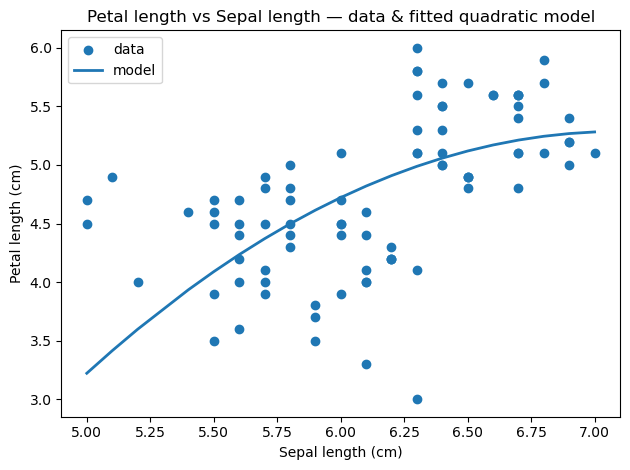

In [17]:
### ANSWER ###
import matplotlib.pyplot as plt

# Use ordered x only
y_hat = quad(x_ordered, *popt)

plt.figure()
plt.scatter(x_ordered, y, label="data")
plt.plot(x_ordered, y_hat, label="model", linewidth=2)

plt.xlabel("Sepal length (cm)")
plt.ylabel("Petal length (cm)")
plt.title("Petal length vs Sepal length — data & fitted quadratic model")
plt.legend()
plt.tight_layout()

# Rubric
# 5 pts for data and best fit
# 5 pts for labels, legend, etc.

#### &#9989;&nbsp; **Question 2.3 Documenting Your Solution Pathway (20 points)**

**Answer the following questions in detail:**
1. Indicate which portions of Part 1 you answered with prior knowledge, and also indicate which portions of Part 1 you answered with the help of outside sources (e.g. generative AI, past assignments, Stack Overflow, Google, etc.) to help you? (1 point)
2. **For the parts were you DID use external resources**, document what sources you used and how they informed your approach.  If you used generative AI, be sure to include *prompts and outputs*. **For the parts where you DID NOT use external resources**, what prior knowledge did you recall to solve the problem? (4 points)
3. Does your solution work? (1 point)
4. **If your solution works**, how do you know it works?  Include any calculations you made, tests you ran, etc. **If your solution DOES NOT work**, how do you know it does not work?  What approaches would you use to verify a correct solution? (4 points)

<font size=+3>&#9998;</font> *Put your answer here.*

---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page.  Go to the "Quizzes" section, find the submission folder link for Quiz #3, and upload it there.